For Figure 5 D SlowFast results

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches 
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, RidgeCV
from scipy.stats import pearsonr, zscore

import sys
sys.path.append('../util_code')

from functions import regression_indices, convert_to_deg

In [2]:
# load the ground truth center positions in pixel space 
human_im_size = 268.51895786308
gt_im_size = 256
df = pd.read_csv('../data/mae_s5_coordinates.csv') # position data
pos = np.squeeze(df['center_x'].values.reshape(-1,1))*(human_im_size/gt_im_size) # convert to the dimensions of the image that the humans made estimates on

In [3]:
# convert labels to eccentricity 
pos = convert_to_deg(pos, human_im_size)

In [4]:
# load the data and reshape it to flatten the 8x8 spatial convolution 
feats_s5 = np.reshape(np.transpose(np.load('../data/slowfast_features/s5_slow_time_feats.pkl.npy', allow_pickle=True),(0,1,3,4,2)),(40,131072,8))
feats_s3 = np.reshape(np.transpose(np.load('../data/slowfast_features/s3_slow_time_feats.pkl.npy', allow_pickle=True),(0,1,3,4,2)),(40,131072,8))
feats_s4 = np.reshape(np.transpose(np.load('../data/slowfast_features/s4_slow_time_feats.pkl.npy', allow_pickle=True),(0,1,3,4,2)),(40,131072,8))

In [5]:
# initialize parameters
n_folds = 4
n_time = 8
n_images = 40
n_shuffle = 100

In [6]:
# Baseline (S5, no adapter) training and testing decoder 
s5_regressors = {} # dictionary that stores all of the regressors
interval = 10 # the number of reps to check for when the best correlation is 
all_preds = np.empty((n_time,n_images, 2)) # 0 - mean predictions, 1 - std
all_stats = np.empty((n_time,2)) # 0 - pearson r, 1 - pearson r std
alpha_values = [0.01, 0.1, 1, 10, 100]
for r in range(n_time):
    feats = feats_s5[:,:,r]
    # preprocess the features by zscoring and applying min-max scaling
    feats = zscore(feats, axis=1)
    feats = (feats - np.min(feats, axis=0)) / (np.max(feats, axis=0) - np.min(feats, axis=0))
    em_array = np.empty((n_images,n_shuffle)) # create an empty vector that can hold the predictions for all 40 images
    for x in range(n_shuffle): # number of predictions you want for each image
        for i in range(n_folds): # number of groups you want to have, do 10 images in each group so 4 groups
            train, test = regression_indices(n_images, number_of_groups=n_folds, test_group= i, SEED= x) # use the function in functions.ipynb to get the indices (i.e., the identifier of the images) in the train and test set
            X_train = feats[train,:] # index the neural data for the images used for training from the neural variable (i.e., neural data = the X variable)
            y_train = pos[train] # index the position data for the images used for training from the x_pos variable (i.e., position data = the y variable)
            X_test = feats[test,:] # index the neural data for the images used for testing from the neural variable
            ridge_cv = RidgeCV(alphas=alpha_values).fit(X_train,y_train) # performs leave-one-out cross validated alpha optimization
            best_alpha = ridge_cv.alpha_
            s5_regressors[f"reg_{r}_{x}_{i}"] = Ridge(alpha=best_alpha) # retrieve the linear regression function from sklearn
            s5_regressors[f"reg_{r}_{x}_{i}"].fit(X_train, y_train) # the regressor trains itself based on the X and y data provided to it
            y_pred = s5_regressors[f"reg_{r}_{x}_{i}"].predict(X_test) # make predictions based on the data set aside for testing
            em_array[test, x] = np.squeeze(y_pred) # assign the prediction values for each image to the test indices and seed column
    corr = np.empty(n_shuffle) 
    for p in range(n_shuffle):
        corr[p] = pearsonr(pos, em_array[:,p])[0]
    all_stats[r,0] = np.nanmean(corr)
    all_stats[r,1] = np.nanstd(corr)
    all_preds[r,:,0] = np.nanmean(em_array,axis= 1)
    all_preds[r,:,1] = np.nanstd(em_array,axis= 1) # get the standard deviation of predictions for each image across all shuffles
    print(f"stats {r} done")

stats 0 done
stats 1 done
stats 2 done
stats 3 done
stats 4 done
stats 5 done
stats 6 done
stats 7 done


In [7]:
# store all the reps from the last timepoint
s5_all_reps = em_array

/tmp/ipykernel_1443776/3403065791.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ob" (-> color='b'). The keyword argument will take precedence.
  plt.errorbar(range(1,feats_s5.shape[2]+1), all_stats[:,0], yerr= all_stats[:,1], xerr= None, fmt= 'ob', color='darkslateblue', ecolor= 'darkslateblue')


<Figure size 600x600 with 0 Axes>

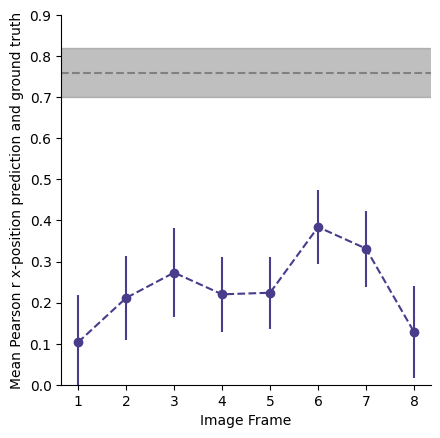

In [8]:
# plot the predictivity across time bins
plt.figure(figsize= (6, 6)) # to ensure that the plot is a square
plt.figure().set_facecolor("white")
plt.gca().set_facecolor("white")
plt.gca().tick_params(colors = "black")
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.errorbar(range(1,feats_s5.shape[2]+1), all_stats[:,0], yerr= all_stats[:,1], xerr= None, fmt= 'ob', color='darkslateblue', ecolor= 'darkslateblue')
plt.plot(range(1,feats_s5.shape[2]+1), all_stats[:, 0], '--', color='darkslateblue')
plt.xlabel('Image Frame')
plt.ylabel('Mean Pearson r x-position prediction and ground truth', color = "black")
plt.ylim(0,0.9) 

plt.axhline(y=0.76,color='grey',linestyle='--') # neural stat

rectangle1 = patches.Rectangle((0,0.76-0.06),9,2*0.06,color='grey',alpha=0.5)

plt.gca().add_patch(rectangle1)

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# plt.savefig('/home/eyakub/scratch/x_slow_s5.eps', format='eps', bbox_inches='tight')

In [9]:
# define a function for making predictions for each season
def seasons_preds(season_feats,n_shuffle): # the number of reps we consider for this particular time point
    all_preds_s = np.empty((n_time,n_images,2)) # 0 - mean predictions, 1 - SD
    all_stats_s = np.empty((n_time,2)) # 0 - pearson r, 1 - pearson r SD
    for r in range(n_time):
        feats = season_feats[:,:,r]
        # preprocess the features by zscoring and applying min-max scaling
        feats = zscore(feats, axis=1)
        feats = (feats - np.min(feats, axis=0)) / (np.max(feats, axis=0) - np.min(feats, axis=0))
        em_array = np.empty((n_images,n_shuffle)) # create an empty vector that can hold the predictions for all 40 images
        for x in range(n_shuffle): # number of predictions you want for each image
            for i in range(n_folds): # number of groups you want to have, do 10 images in each group so 4 groups
                train, test = regression_indices(n_images, number_of_groups=n_folds, test_group= i, SEED= x)
                X_test = feats[test,:] # index the neural data for the images used for testing from the neural variable
                y_pred = s5_regressors[f"reg_{r}_{x}_{i}"].predict(X_test) # make predictions based on the data set aside for testing
                em_array[test, x] = np.squeeze(y_pred) # assign the prediction values for each image to the test indices and seed column
        all_preds_s[r,:,0] = np.nanmean(em_array, axis= 1)
        all_preds_s[r,:,1] = np.std(em_array,axis= 1) # get the standard deviation of predictions for each image
        corr = np.empty(n_shuffle) 
        for p in range(n_shuffle):
            corr[p] = pearsonr(np.squeeze(pos), em_array[:,p])[0]
        all_stats_s[r,0] = np.nanmean(corr)
        all_stats_s[r,1] = np.std(corr)
    return all_preds_s, all_stats_s, em_array

In [10]:
# Make predictions for S3 (right adapted) and S4 (left adapted)
all_preds_s3, all_stats_s3, s3_all_reps = seasons_preds(feats_s3,n_shuffle=100)
all_preds_s4, all_stats_s4, s4_all_reps = seasons_preds(feats_s4,n_shuffle=100)

In [11]:
# correlate S3 and S4 with S5
s53_corr = []
s54_corr = []

for i in range(n_shuffle):
    tmp_s5 = np.squeeze(s5_all_reps[:,i])
    tmp_s3 = np.squeeze(s3_all_reps[:,i])
    tmp_s4 = np.squeeze(s4_all_reps[:,i])

    s53_corr.append(pearsonr(tmp_s5,tmp_s3)[0])
    s54_corr.append(pearsonr(tmp_s5,tmp_s4)[0])

/tmp/ipykernel_1443776/2763145300.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ob" (-> color='b'). The keyword argument will take precedence.
  plt.errorbar(range(1,feats_s5.shape[2]+1), all_stats[:,0], yerr= all_stats[:,1], xerr= None, fmt= 'ob', color='darkslateblue', ecolor= 'darkslateblue')
/tmp/ipykernel_1443776/2763145300.py:16: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ob" (-> color='b'). The keyword argument will take precedence.
  plt.errorbar(range(1,feats_s5.shape[2]+1), all_stats_s3[:,0], yerr= all_stats_s3[:,1], xerr= None, fmt= 'ob', color='darkgreen', ecolor='darkgreen', label = 'Right Adapter')
/tmp/ipykernel_1443776/2763145300.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ob" (-> color='b'). The keyword argument will take precedence.
  plt.errorbar(range(1,feats_s5.shape[2]+1), all_stats_s4[:,0], yerr= all_st

<Figure size 600x600 with 0 Axes>

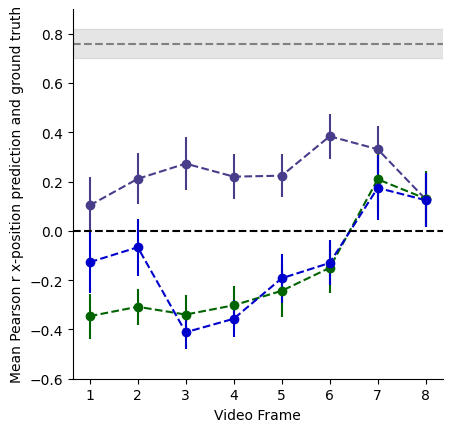

In [12]:
# merged s3 and s4 plot

# formatting
plt.figure(figsize= (6, 6)) # to ensure that the plot is a square
plt.figure().set_facecolor("white")
plt.gca().set_facecolor("white")
plt.gca().tick_params(colors = "black")
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# plotting
plt.errorbar(range(1,feats_s5.shape[2]+1), all_stats[:,0], yerr= all_stats[:,1], xerr= None, fmt= 'ob', color='darkslateblue', ecolor= 'darkslateblue')
plt.plot(range(1,feats_s5.shape[2]+1), all_stats[:, 0], '--', color='darkslateblue')
plt.errorbar(range(1,feats_s5.shape[2]+1), all_stats_s3[:,0], yerr= all_stats_s3[:,1], xerr= None, fmt= 'ob', color='darkgreen', ecolor='darkgreen', label = 'Right Adapter')
plt.plot(range(1,feats_s5.shape[2]+1), all_stats_s3[:, 0], '--', color='darkgreen')
plt.errorbar(range(1,feats_s5.shape[2]+1), all_stats_s4[:,0], yerr= all_stats_s4[:,1], xerr= None, fmt= 'ob', color='mediumblue', ecolor='mediumblue', label = 'Left Adapter')
plt.plot(range(1,feats_s5.shape[2]+1), all_stats_s4[:, 0], '--', color='mediumblue')

plt.axhline(y=0.76,color='grey', linestyle='--') # neural stat
rectangle2 = patches.Rectangle((0,(0.76-0.06)),9,2*0.06, color='grey', alpha=0.2)
plt.gca().add_patch(rectangle2)

plt.axhline(y=0,color='black',linestyle='--')

# more formatting
plt.xlabel('Video Frame')
plt.ylabel('Mean Pearson r x-position prediction and ground truth')
plt.ylim(-0.6,0.9)

# make the plot square
x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# plt.savefig('/home/eyakub/scratch/x_slow_s34.eps', format='eps', bbox_inches='tight')


In [13]:
# plotting range
pos_range = np.linspace(min(pos),max(pos))

/tmp/ipykernel_1443776/468427903.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ob" (-> color='b'). The keyword argument will take precedence.
  plt.errorbar(all_preds[7,:,0],all_preds_s3[7,:,0],xerr=all_preds[7,:,1],yerr=all_preds_s3[7,:,1], fmt='ob', color='green')
/tmp/ipykernel_1443776/468427903.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ob" (-> color='b'). The keyword argument will take precedence.
  plt.errorbar(all_preds[7,:,0],all_preds_s4[7,:,0],xerr=all_preds[7,:,1],yerr=all_preds_s4[7,:,1], fmt='ob', color='blue')


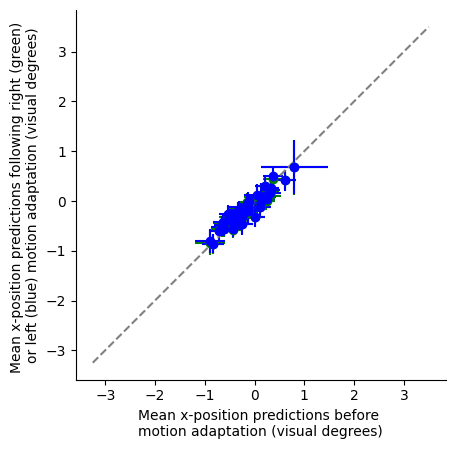

In [14]:
# s3 vs s4 predictions
#format
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.errorbar(all_preds[7,:,0],all_preds_s3[7,:,0],xerr=all_preds[7,:,1],yerr=all_preds_s3[7,:,1], fmt='ob', color='green')
plt.errorbar(all_preds[7,:,0],all_preds_s4[7,:,0],xerr=all_preds[7,:,1],yerr=all_preds_s4[7,:,1], fmt='ob', color='blue')
plt.plot(pos_range,pos_range, color='grey', linestyle='--')

plt.xlabel('Mean x-position predictions before \nmotion adaptation (visual degrees)')
plt.ylabel('Mean x-position predictions following right (green) \nor left (blue) motion adaptation (visual degrees)')

x0,x1 = plt.gca().get_xlim()
y0,y1 = plt.gca().get_ylim()

plt.gca().set_aspect(abs(x1-x0)/abs(y1-y0))

# plt.savefig('/home/eyakub/scratch/x_slow_s34_scatter.eps', format='eps', bbox_inches='tight')

In [17]:
# compare the per-image deltas 
model_delta = all_preds_s4[7,:,0] - all_preds_s3[7,:,0]
np.save("../data/slowfastx_nonadapt_delta",model_delta)